In [1]:
# Design a 12 ns NOT gate (pi rotation) on the computational subspace {|0>, |1>}
# of a transmon qubit.
# The control pulse is optimized to:
#   - Suppress leakage into the non-computational level |2>,
#   - Minimize the total pulse energy, given by the integral (Ωx^2 + Ωy^2) dt.
# The system is modeled with an anharmonicity of -100 MHz.
# Estimated script runtime: ~5 seconds.

# AUTHOR:
#     Leo Van Damme / Technical University of Munich, 2025

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from grape_scq import Transmon, GateTarget, OptimizationProblem, GrapeOptimizer, initial_guess

In [3]:
# Physical system and target
system = Transmon(
    n_levels=3,          # Number of energy levels
    anharmonicity=-100e6,  # Anharmonicity in Hz
)
target = GateTarget(
    matrix=[[0, 1], [1, 0]],  # Target gate (NOT gate)
    subspace=[0, 1],          # Computational states indices
)
problem = OptimizationProblem(
    system, target,
    n_steps=120,             # Number of time steps
    dt=0.1e-9,                # Timestep in s.
    reference_amplitude=10e6, # Reference pulse amplitude
)

In [4]:
# Initial guess: Drag-like pulse
pulse0 = initial_guess.cos_drag(problem, theta=np.pi)

In [5]:
# Optimize the pulse
optimizer = GrapeOptimizer(
    max_iter=500,        # Maximum number of iterations
    minimize_energy=True,  # Find minimum-energy solution
)
result = optimizer.optimize(problem, pulse0)

Compiling cost function... Done.
Pre-optimization = 10/10, cost (+ penalty) = -0.000000
GRAPE optimization result
  cost:      0.019948 -> -0.000000
  fidelity:  0.980052 -> 1.000000
  iterations: 1 (+ 139 pre-optimization)
  message:   CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


In [6]:
# Compare fidelity
initial_result_fidelity = 1 - result.initial_cost
print(f"Fidelity of DRAG pulse = {initial_result_fidelity*100:.3f} %")
print(f"Fidelity of GRAPE pulse = {result.average_fidelity*100:.3f} %")

Fidelity of DRAG pulse = 98.005 %
Fidelity of GRAPE pulse = 100.000 %


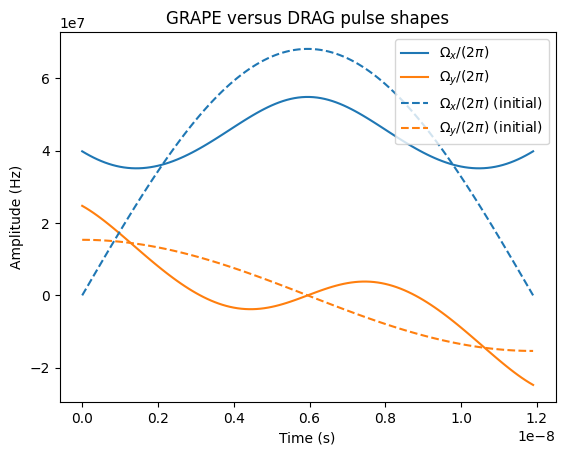

In [7]:
# Display in-phase and quadrature pulse components (GRAPE vs. initial DRAG guess)
result.plot_pulse(compare_to_initial=True)
plt.title("GRAPE versus DRAG pulse shapes")
plt.show()

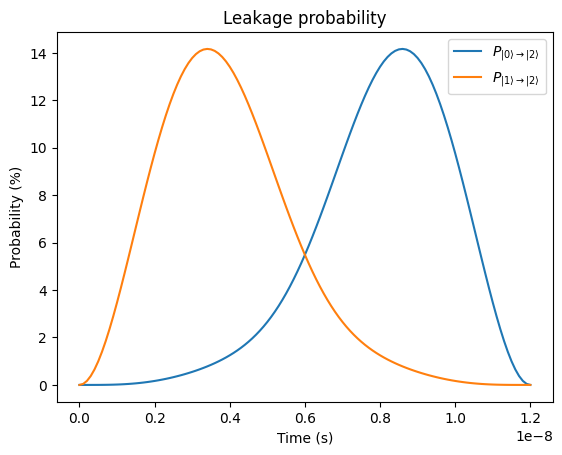

In [8]:
# Compute and display leakage as a function of time
plt.figure()
plt.plot(problem.t, result.population(0, 2) * 100, label=r'$P_{|0\rangle\rightarrow|2\rangle}$')
plt.plot(problem.t, result.population(1, 2) * 100, label=r'$P_{|1\rangle\rightarrow|2\rangle}$')
plt.xlabel('Time (s)')
plt.ylabel('Probability (%)')
plt.legend()
plt.title("Leakage probability")
plt.show()